## Imports


In [3]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.model_selection import train_test_split,GridSearchCV
import sklearn.metrics as metrics # For confusion matrix
from sklearn.linear_model import LinearRegression,Lasso
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [2]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 80.1 MB/s eta 0:00:00ta 0:00:01


## Data reduction


In [4]:
import dask.dataframe as dd

# pd.options.display.float_format = '{:.2f}'.format
df = pd.read_parquet('./yellow_tripdata_2022-01.parquet')

df_cleaned = df.dropna(subset=['passenger_count','RatecodeID','store_and_fwd_flag','congestion_surcharge','airport_fee'])

reduced_df = df_cleaned.sample(n=25000, random_state=42)
reduced_df.to_csv('./reduced_dataset.csv', index=False)
reduced_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 1298294 to 338650
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               25000 non-null  int64         
 1   tpep_pickup_datetime   25000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  25000 non-null  datetime64[us]
 3   passenger_count        25000 non-null  float64       
 4   trip_distance          25000 non-null  float64       
 5   RatecodeID             25000 non-null  float64       
 6   store_and_fwd_flag     25000 non-null  object        
 7   PULocationID           25000 non-null  int64         
 8   DOLocationID           25000 non-null  int64         
 9   payment_type           25000 non-null  int64         
 10  fare_amount            25000 non-null  float64       
 11  extra                  25000 non-null  float64       
 12  mta_tax                25000 non-null  float64       
 13 

## Visulaization

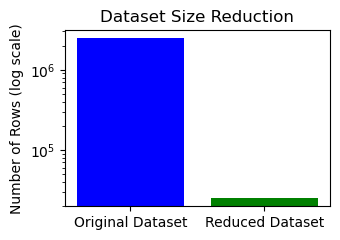

In [5]:
original_size = len(df)
reduced_size = len(reduced_df)

# Labels and values
labels = ['Original Dataset', 'Reduced Dataset']
sizes = [original_size, reduced_size]

# Create bar chart
plt.figure(figsize=(3.5, 2.5))  # Single-column width
plt.bar(labels, sizes, color=['blue', 'green'])
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.ylabel('Number of Rows (log scale)')
plt.title('Dataset Size Reduction')
plt.tight_layout()
plt.savefig('./Figures/Datareduct',dpi=300)
plt.show()

## Describe data

In [6]:
reduced_df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,25000.00000,25000,25000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,1.69764,2022-01-17 00:58:38.527959,2022-01-17 01:13:20.625520,1.395480,3.115978,1.447000,166.161400,164.013840,1.231960,12.669806,1.031924,0.491320,2.365824,0.373600,0.296736,18.880993,2.280500,0.082250
min,1.00000,2022-01-01 00:10:16,2022-01-01 00:18:13,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-200.000000,-4.500000,-0.500000,0.000000,-18.000000,-0.300000,-190.300000,-2.500000,-1.250000
25%,1.00000,2022-01-09 13:55:12.500000,2022-01-09 14:03:44,1.000000,1.050000,1.000000,132.000000,113.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,11.300000,2.500000,0.000000
50%,2.00000,2022-01-17 09:21:21,2022-01-17 09:31:18,1.000000,1.730000,1.000000,162.000000,162.000000,1.000000,9.000000,0.500000,0.500000,2.000000,0.000000,0.300000,14.300000,2.500000,0.000000
75%,2.00000,2022-01-24 13:03:19.750000,2022-01-24 13:20:04.750000,1.000000,3.100000,1.000000,234.000000,236.000000,1.000000,13.500000,2.500000,0.500000,3.000000,0.000000,0.300000,19.800000,2.500000,0.000000
max,2.00000,2022-02-01 03:30:04,2022-02-01 06:01:41,6.000000,89.400000,99.000000,265.000000,265.000000,4.000000,330.000000,8.250000,0.500000,86.000000,32.500000,0.300000,413.010000,2.500000,1.250000
std,0.45929,NaN,NaN,0.984558,4.158916,6.162213,64.770926,70.520164,0.460959,12.077320,1.237176,0.082734,2.754190,1.679861,0.043889,15.024932,0.745045,0.312332


## Data Preprocessing / Transformation



## Create duration column

In [7]:
reduced_df['duration'] = (reduced_df['tpep_dropoff_datetime'] - reduced_df['tpep_pickup_datetime'])/np.timedelta64(1,'m')
reduced_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 1298294 to 338650
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               25000 non-null  int64         
 1   tpep_pickup_datetime   25000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  25000 non-null  datetime64[us]
 3   passenger_count        25000 non-null  float64       
 4   trip_distance          25000 non-null  float64       
 5   RatecodeID             25000 non-null  float64       
 6   store_and_fwd_flag     25000 non-null  object        
 7   PULocationID           25000 non-null  int64         
 8   DOLocationID           25000 non-null  int64         
 9   payment_type           25000 non-null  int64         
 10  fare_amount            25000 non-null  float64       
 11  extra                  25000 non-null  float64       
 12  mta_tax                25000 non-null  float64       
 13 

## Three important column to predict outliers are
- trip_distance
- fare_amount
- duration

### Visualizing before outlier analysis

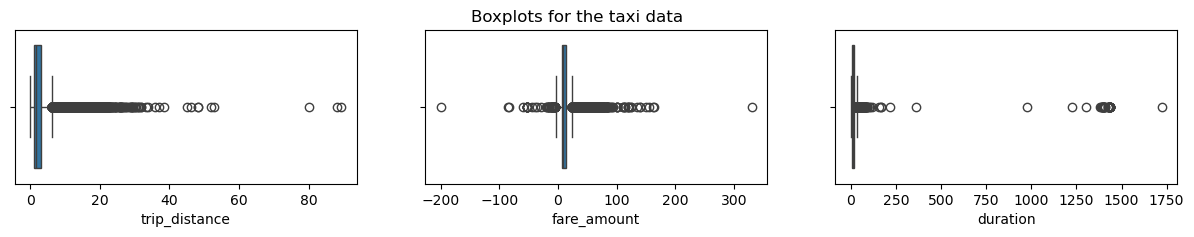

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 2))
fig.suptitle('Boxplots for the taxi data')
sns.boxplot(ax=axes[0], x=reduced_df['trip_distance'])
sns.boxplot(ax=axes[1], x=reduced_df['fare_amount'])
sns.boxplot(ax=axes[2], x=reduced_df['duration'])
plt.show();

## Coustum outlier detection function

In [9]:
def oulierDetect(name_list,factor):
    for x in name_list:
        # if values less than zeros are considered as zeros
        reduced_df.loc[reduced_df[x] < 0, x] = 0
        # seting q3 value
        q3 = reduced_df[x].quantile(0.75)
        # setting the upper cap
        upper_cap = q3 + (factor * (q3 - reduced_df[x].quantile(0.25)))
        
        reduced_df.loc[reduced_df[x] > upper_cap, x] = upper_cap

## The trip distance column outliers


In [10]:
sorted(set(reduced_df['trip_distance']))[:10]

[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09]

In [11]:
sum(reduced_df['trip_distance']==0)

284

In [13]:
oulierDetect(['trip_distance'],14)
reduced_df['trip_distance'].describe()

count    25000.000000
mean         3.104659
std          4.027286
min          0.000000
25%          1.050000
50%          1.730000
75%          3.100000
max         31.800000
Name: trip_distance, dtype: float64

## Fare amount outlier

In [14]:
oulierDetect(['fare_amount'], 6)
reduced_df['fare_amount'].describe()

count    25000.000000
mean        12.587528
std         10.884256
min          0.000000
25%          6.500000
50%          9.000000
75%         13.500000
max         55.500000
Name: fare_amount, dtype: float64

## Duration Outlier detection

In [15]:
reduced_df.loc[reduced_df['duration'] < 0, 'duration'] = 0
reduced_df['duration'].min()

0.0

In [16]:
oulierDetect(['duration'], 6)
reduced_df['duration'].describe()


count    25000.000000
mean        12.805615
std          9.871953
min          0.000000
25%          6.350000
50%         10.166667
75%         16.133333
max         74.833333
Name: duration, dtype: float64

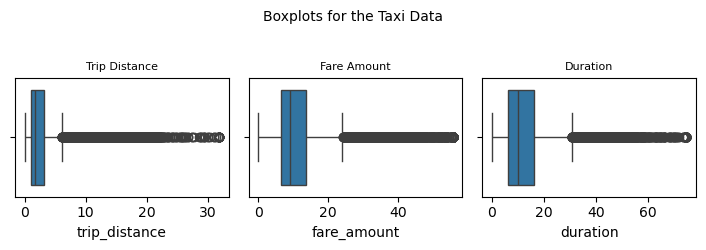

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(7.16, 2.5))  
fig.suptitle('Boxplots for the Taxi Data', fontsize=10)

# Plot boxplots
sns.boxplot(ax=axes[0], x=reduced_df['trip_distance'])
axes[0].set_title('Trip Distance', fontsize=8)
sns.boxplot(ax=axes[1], x=reduced_df['fare_amount'])
axes[1].set_title('Fare Amount', fontsize=8)
sns.boxplot(ax=axes[2], x=reduced_df['duration'])
axes[2].set_title('Duration', fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save the figure
plt.savefig('./Figures/PostOutlierAnalysis.png', dpi=300) 
plt.show()

## Creating a temporoary column pickDrop

In [18]:
reduced_df['pickDrop'] = reduced_df['PULocationID'].astype(str) + ' ' + reduced_df['DOLocationID'].astype(str)
reduced_df['pickDrop'].head(2)

1298294    233 141
469658      48 186
Name: pickDrop, dtype: object

## Feature Engineering

### Mean Distance Column

In [19]:
pickDrop_Dis = reduced_df.groupby('pickDrop').mean(numeric_only=True)[['trip_distance']]
pickDrop_Dis[:10]

pickDrop_Dis_dict = pickDrop_Dis.to_dict()


pickDrop_Dis_dict = pickDrop_Dis_dict['trip_distance']

# len(pickDrop_Dis_dict)

reduced_df['mean_dis'] = reduced_df['pickDrop']


reduced_df['mean_dis'] = reduced_df['mean_dis'].map(pickDrop_Dis_dict)


reduced_df[(reduced_df['PULocationID']==100) & (reduced_df['DOLocationID']==231)][['mean_dis']]

,mean_dis
905168,3.357143
1526413,3.357143
1270028,3.357143
37591,3.357143
1390900,3.357143
1750897,3.357143
2085901,3.357143


### Mean Duriation Column

In [20]:
grouped = reduced_df.groupby('pickDrop').mean(numeric_only=True)[['duration']]
grouped

grouped_dict = grouped.to_dict()
grouped_dict = grouped_dict['duration']

reduced_df['mean_duration'] = reduced_df['pickDrop']
reduced_df['mean_duration'] = reduced_df['mean_duration'].map(grouped_dict)

reduced_df[(reduced_df['PULocationID']==100) & (reduced_df['DOLocationID']==231)][['mean_duration']]

,mean_duration
905168,19.490476
1526413,19.490476
1270028,19.490476
37591,19.490476
1390900,19.490476
1750897,19.490476
2085901,19.490476


### Creating new columns for days and months

In [21]:

reduced_df['dd'] = reduced_df['tpep_pickup_datetime'].dt.day_name().str.lower()

reduced_df['mm'] = reduced_df['tpep_pickup_datetime'].dt.strftime('%b').str.lower()

reduced_df['dd']

1298294      tuesday
469658        friday
1188324       monday
1508389       friday
824431     wednesday
             ...    
2301695       sunday
1644570     saturday
616078        sunday
2206717       friday
338650      thursday
Name: dd, Length: 25000, dtype: object

### Creating a Peak hours columns

In [22]:

reduced_df['peek_t'] = reduced_df['tpep_pickup_datetime'].dt.hour

# If day is Saturday or Sunday, impute 0 in `rush_hour` column
reduced_df.loc[reduced_df['dd'].isin(['saturday', 'sunday']), 'peek_t'] = 0
def peek_analzer(hour):
    if 6 <= hour['peek_t'] < 10:
        val = 1
    elif 16 <= hour['peek_t'] < 20:
        val = 1
    else:
        val = 0
    return val
reduced_df['peek_t'] = reduced_df.apply(peek_analzer, axis=1)
reduced_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,airport_fee,duration,pickDrop,mean_dis,mean_duration,dd,mm,peek_t
1298294,1,2022-01-18 16:47:56,2022-01-18 16:57:48,1.0,1.40,1.0,Y,233,141,1,...,15.35,2.5,0.0,9.866667,233 141,1.546667,7.765972,tuesday,jan,1
469658,1,2022-01-07 20:06:59,2022-01-07 20:14:50,2.0,1.70,1.0,N,48,186,1,...,13.55,2.5,0.0,7.850000,48 186,1.302727,8.565909,friday,jan,0
1188324,1,2022-01-17 06:53:38,2022-01-17 07:02:58,1.0,4.40,1.0,Y,74,244,2,...,14.80,0.0,0.0,9.333333,74 244,3.940000,10.975000,monday,jan,1
1508389,2,2022-01-21 07:29:59,2022-01-21 07:46:58,1.0,5.94,1.0,N,238,13,1,...,27.36,2.5,0.0,16.983333,238 13,6.105000,17.641667,friday,jan,1
824431,1,2022-01-12 16:32:45,2022-01-12 16:43:26,1.0,1.30,1.0,N,237,140,1,...,14.15,2.5,0.0,10.683333,237 140,0.965435,7.788768,wednesday,jan,1


## The mean duration correlates with target value

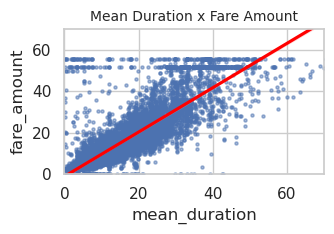

In [23]:
sns.set(style='whitegrid')


f = plt.figure(figsize=(3.5, 2.5))  
sns.regplot(x=reduced_df['mean_duration'], y=reduced_df['fare_amount'],
            scatter_kws={'alpha': 0.5, 's': 5},
            line_kws={'color': 'red'})
plt.ylim(0, 70)
plt.xlim(0, 70)
plt.title('Mean Duration x Fare Amount', fontsize=10)
plt.tight_layout()
plt.savefig('./Figures/MeanDuration_FareAmount.png', dpi=300)  # Ensure the file extension is included
plt.show()

In [24]:
reduced_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 1298294 to 338650
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               25000 non-null  int64         
 1   tpep_pickup_datetime   25000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  25000 non-null  datetime64[us]
 3   passenger_count        25000 non-null  float64       
 4   trip_distance          25000 non-null  float64       
 5   RatecodeID             25000 non-null  float64       
 6   store_and_fwd_flag     25000 non-null  object        
 7   PULocationID           25000 non-null  int64         
 8   DOLocationID           25000 non-null  int64         
 9   payment_type           25000 non-null  int64         
 10  fare_amount            25000 non-null  float64       
 11  extra                  25000 non-null  float64       
 12  mta_tax                25000 non-null  float64       
 13 

## Creating final dataframe for algorithms


In [25]:
rdDf = reduced_df.copy()

rdDf = rdDf.drop(['tpep_dropoff_datetime', 'tpep_pickup_datetime',
               'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID',
               'payment_type', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge','airport_fee',
               'total_amount', 'tpep_dropoff_datetime', 'tpep_pickup_datetime', 'duration',"congestion_surcharge","pickDrop","dd","mm"
               ], axis=1)
# filling missing values for passsenger count
# rdDf['passenger_count'].fillna(1, inplace=True)

rdDf.info()


<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 1298294 to 338650
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   VendorID         25000 non-null  int64  
 1   passenger_count  25000 non-null  float64
 2   fare_amount      25000 non-null  float64
 3   mean_dis         25000 non-null  float64
 4   mean_duration    25000 non-null  float64
 5   peek_t           25000 non-null  int64  
dtypes: float64(4), int64(2)
memory usage: 1.3 MB


### Pairplot between features and target

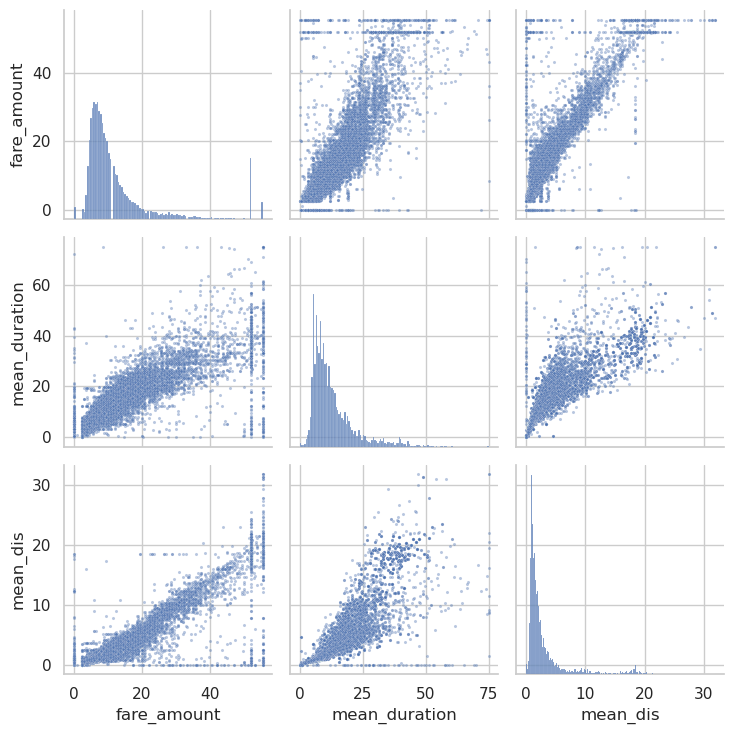

In [26]:
sns.set(style='whitegrid')
pairplot = sns.pairplot(rdDf[['fare_amount', 'mean_duration', 'mean_dis']],
                        plot_kws={'alpha': 0.4, 's': 5})
plt.tight_layout()
pairplot.savefig('./Figures/Pairplot.png', dpi=300)  # Ensure the file extension is included
plt.show()

### Finding correlations

In [27]:
rdDf.corr(method='pearson')

,VendorID,passenger_count,fare_amount,mean_dis,mean_duration,peek_t
VendorID,1.000000,0.129279,0.003147,0.019076,-0.001180,-0.005573
passenger_count,0.129279,1.000000,0.014733,0.013765,0.008318,-0.035489
fare_amount,0.003147,0.014733,1.000000,0.912105,0.853176,-0.024326
mean_dis,0.019076,0.013765,0.912105,1.000000,0.860656,-0.028520
mean_duration,-0.001180,0.008318,0.853176,0.860656,1.000000,-0.013320
peek_t,-0.005573,-0.035489,-0.024326,-0.028520,-0.013320,1.000000


#### Strongest Correlations:

- fare_amount with mean_dis (0.89)
- fare_amount with mean_duration (0.86)
- mean_dis with mean_duration (0.88)


#### Heat map

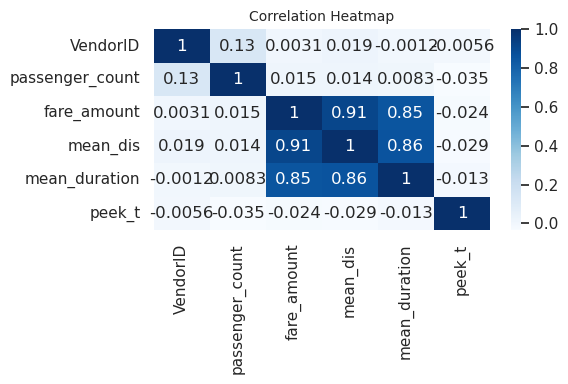

In [28]:
sns.set(style='whitegrid')
plt.figure(figsize=(6,4)) 
sns.heatmap(rdDf.corr(method='pearson'), annot=True, cmap='Blues')
plt.title('Correlation Heatmap', fontsize=10)
plt.tight_layout()
plt.savefig('./Figures/CorrelationHeatmap.png', dpi=300)  # Ensure the file extension is included
plt.show()

## diffrentiating X and y which is features and target

In [29]:

X = rdDf.drop(columns=['fare_amount'])

y = rdDf[['fare_amount']]

# Display first few rows
X.head()

,VendorID,passenger_count,mean_dis,mean_duration,peek_t
1298294,1,1.0,1.546667,7.765972,1
469658,1,2.0,1.302727,8.565909,0
1188324,1,1.0,3.940000,10.975000,1
1508389,2,1.0,6.105000,17.641667,1
824431,1,1.0,0.965435,7.788768,1


In [30]:
# X['VendorID'] = X['VendorID'].astype(str)

# X = pd.get_dummies(X, drop_first=True)
# X = X.drop(columns=['VendorID_6'])
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 1298294 to 338650
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   VendorID         25000 non-null  int64  
 1   passenger_count  25000 non-null  float64
 2   mean_dis         25000 non-null  float64
 3   mean_duration    25000 non-null  float64
 4   peek_t           25000 non-null  int64  
dtypes: float64(3), int64(2)
memory usage: 1.1 MB


## Training the data Linear regression
- Feature data set is -> VendorID	passenger_count	mean_dis	mean_duration	peek_t
- Target value is fare_amount

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [32]:

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
# X_train_scaled = np.insert(X_train_scaled, 0, 1, axis=1)
print('X_train scaled:', X_train_scaled)
X_train.info()
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)


X_train scaled: [[ 0.65972344  0.61041912 -0.34737175 -0.24074472 -0.67396452]
 [-1.51578667 -0.40264058  0.50941772  1.47511678 -0.67396452]
 [ 0.65972344 -0.40264058  0.54256951  0.76594123  1.48375764]
 ...
 [ 0.65972344 -0.40264058  0.12604708  0.69556747  1.48375764]
 [ 0.65972344 -0.40264058 -0.57920757 -0.97111771 -0.67396452]
 [-1.51578667 -0.40264058 -0.55175167 -0.74245957  1.48375764]]
<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 2351524 to 1558322
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   VendorID         20000 non-null  int64  
 1   passenger_count  20000 non-null  float64
 2   mean_dis         20000 non-null  float64
 3   mean_duration    20000 non-null  float64
 4   peek_t           20000 non-null  int64  
dtypes: float64(3), int64(2)
memory usage: 937.5 KB


### Visulizing polynominal features

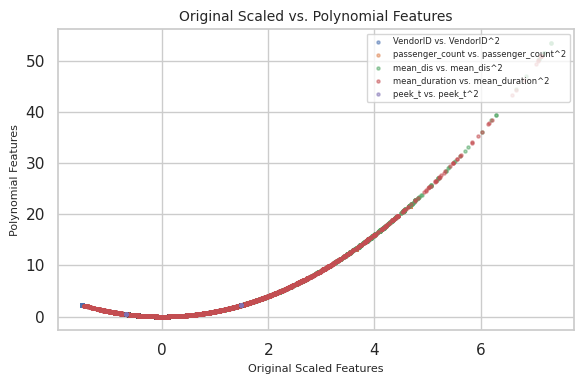

In [33]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
poly_feature_names = poly.get_feature_names_out(X_train.columns)
X_train_poly_df = pd.DataFrame(X_train_poly, columns=poly_feature_names)
# Create the scatter plot with IEEE format size
plt.figure(figsize=(6,4))  # Single-column width

# Plot original scaled features vs. polynomial features
for feature in X_train.columns:
    if f'{feature}^2' in X_train_poly_df.columns:
        plt.scatter(X_train_scaled_df[feature], X_train_poly_df[f'{feature}^2'], alpha=0.5, s=5, label=f'{feature} vs. {feature}^2')
# Set labels and title
plt.xlabel('Original Scaled Features', fontsize=8)
plt.ylabel('Polynomial Features', fontsize=8)
plt.title('Original Scaled vs. Polynomial Features', fontsize=10)
plt.legend(fontsize=6, loc='upper right')

# Adjust layout to fit within the figure size
plt.tight_layout()
plt.savefig('./Figures/PolynominalFeatures.png', dpi=300)
plt.show()

## Visualization

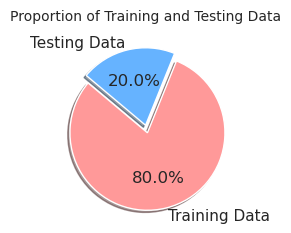

In [34]:
sizes = [len(X_train), len(X_test)] 
labels = ['Training Data', 'Testing Data']
colors = ['#ff9999','#66b3ff']
explode = (0.1, 0) 

plt.figure(figsize=(3.5, 2.5)) 
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140)
plt.title('Proportion of Training and Testing Data', fontsize=10)
plt.tight_layout()
plt.savefig('./Figures/TrainingTestingProportion.png', dpi=300)  
plt.show()

## LinearRegression

In [35]:
lr=LinearRegression()
lr.fit(X_train_poly, y_train)


LinearRegression()

In [36]:
r_sq = lr.score(X_train_poly, y_train)
print('Coefficient of determination:', r_sq)
y_pred_train = lr.predict(X_train_poly)
print('R^2:', r2_score(y_train, y_pred_train))
print('MAE:', mean_absolute_error(y_train, y_pred_train))
print('MSE:', mean_squared_error(y_train, y_pred_train))
print('RMSE:',np.sqrt(mean_squared_error(y_train, y_pred_train)))

Coefficient of determination: 0.8516037694611528
R^2: 0.8516037694611528
MAE: 1.9904343686523436
MSE: 17.564573088135152
RMSE: 4.191010986401151


In [37]:
X_test_scaled = scaler.transform(X_test)
# X_test_scaled = np.insert(X_test_scaled, 0, 1, axis=1)
X_test_poly = poly.transform(X_test_scaled)

In [38]:
r_sq_test = lr.score(X_test_poly, y_test)
print('Coefficient of determination:', r_sq_test)
y_pred_test = lr.predict(X_test_poly)
print('R^2:', r2_score(y_test, y_pred_test))
print('MAE:', mean_absolute_error(y_test,y_pred_test))
print('MSE:', mean_squared_error(y_test, y_pred_test))
print('RMSE:',np.sqrt(mean_squared_error(y_test, y_pred_test)))

Coefficient of determination: 0.8742437131825628
R^2: 0.8742437131825628
MAE: 1.8863582949218747
MSE: 14.947487429080141
RMSE: 3.8661980586979943


### implenting the OLS for summary

In [56]:
import statsmodels.api as sm
scale = StandardScaler()
y1 = rdDf[['fare_amount']]
X1 = rdDf.drop(columns=['fare_amount'])
X1['VendorID'] = X1['VendorID'].astype(int)
X1[['VendorID','passenger_count', 'mean_dis','mean_duration','peek_t']] = scale.fit_transform(X1[[ 'VendorID','passenger_count', 'mean_dis','mean_duration','peek_t']].values)
X1 = sm.add_constant(X1)

# print (X)
est = sm.OLS(y1, X1).fit()

print(est.summary())

                            OLS Regression Results                            
Dep. Variable:            fare_amount   R-squared:                       0.850
Model:                            OLS   Adj. R-squared:                  0.850
Method:                 Least Squares   F-statistic:                 2.832e+04
Date:                Fri, 19 Jul 2024   Prob (F-statistic):               0.00
Time:                        14:00:51   Log-Likelihood:                -71444.
No. Observations:               25000   AIC:                         1.429e+05
Df Residuals:                   24994   BIC:                         1.429e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              12.5875      0.027    4

### Results -> actual vs predicted

In [39]:
results = pd.DataFrame(data={'actual': y_test['fare_amount'],
                             'predicted': y_pred_test.ravel()})
results['residual'] = results['actual'] - results['predicted']
results.head()

,actual,predicted,residual
199184,18.0,18.139893,-0.139893
1551566,6.5,7.975342,-1.475342
254730,5.0,7.258545,-2.258545
1209494,12.5,13.484131,-0.984131
1383344,7.5,7.233398,0.266602


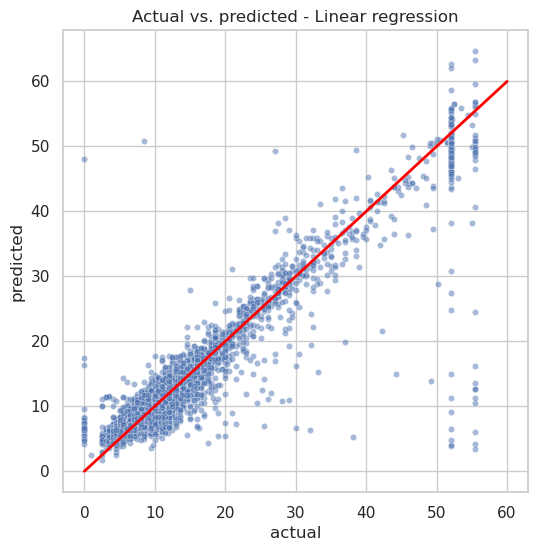

In [40]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.set(style='whitegrid')
sns.scatterplot(x='actual',
                y='predicted',
                data=results,
                s=20,
                alpha=0.5,
                ax=ax
)
plt.plot([0,60], [0,60], c='red', linewidth=2)
plt.title('Actual vs. predicted - Linear regression');

In [41]:
results['residual'].mean()

0.009369369140625005

In [42]:
print(X_train['mean_dis'].std())


print(9.208656	 / X_train['mean_dis'].std())


3.921455490136626
2.3482750277701516


## Random Forest Algorithm

In [43]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

In [44]:
# # Train the model
rf.fit(X_train_poly, y_train)

# # Make predictions
y_pred1 = rf.predict(X_test_poly)

# # Evaluate the model
mse1 = mean_squared_error(y_test, y_pred1)
r21 = r2_score(y_test, y_pred1)

print(f'Mean Squared Error: {mse1}')
print(f'R^2 Score: {r21}')
print('RMSE:',np.sqrt(mean_squared_error(y_test, y_pred1)))

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Mean Squared Error: 16.46140682506779
R^2 Score: 0.8615067978525714
RMSE: 4.0572659297940765


## XGBoost Algorithm

In [45]:
xgb_model = XGBRegressor(
    objective='reg:squarederror',  # for regression task
    max_depth=6,                   # maximum depth of a tree
    learning_rate=0.3,             # learning rate
    n_estimators=100,              # number of trees to fit
    subsample=0.8,                 # subsample ratio of the training instances
    colsample_bytree=0.8,          # subsample ratio of columns when constructing each tree
    random_state=42
)

In [ ]:
# Train the model
xgb_model.fit(X_train_poly, y_train)

# Make predictions
y_pred2 = xgb_model.predict(X_test_poly)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred2)
r2 = r2_score(y_test, y_pred2)

print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')
print('RMSE:',np.sqrt(mean_squared_error(y_test, y_pred2)))


In [71]:
models = ['Linear Regression', 'Random Forest', 'XGBoost']
predictions = [y_pred_test, y_pred1, y_pred2]

for model_name, pred in zip(models, predictions):
    mse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print(f'{model_name} - Mean Squared Error: {mse}, R^2 Score: {r2}')

Linear Regression - Mean Squared Error: 14.948803713718371, R^2 Score: 0.8742326390091082
Random Forest - Mean Squared Error: 16.466342465155613, R^2 Score: 0.8614652732971264
XGBoost - Mean Squared Error: 15.6139256009934, R^2 Score: 0.8686368465423584


### Sactter plot for algorithms

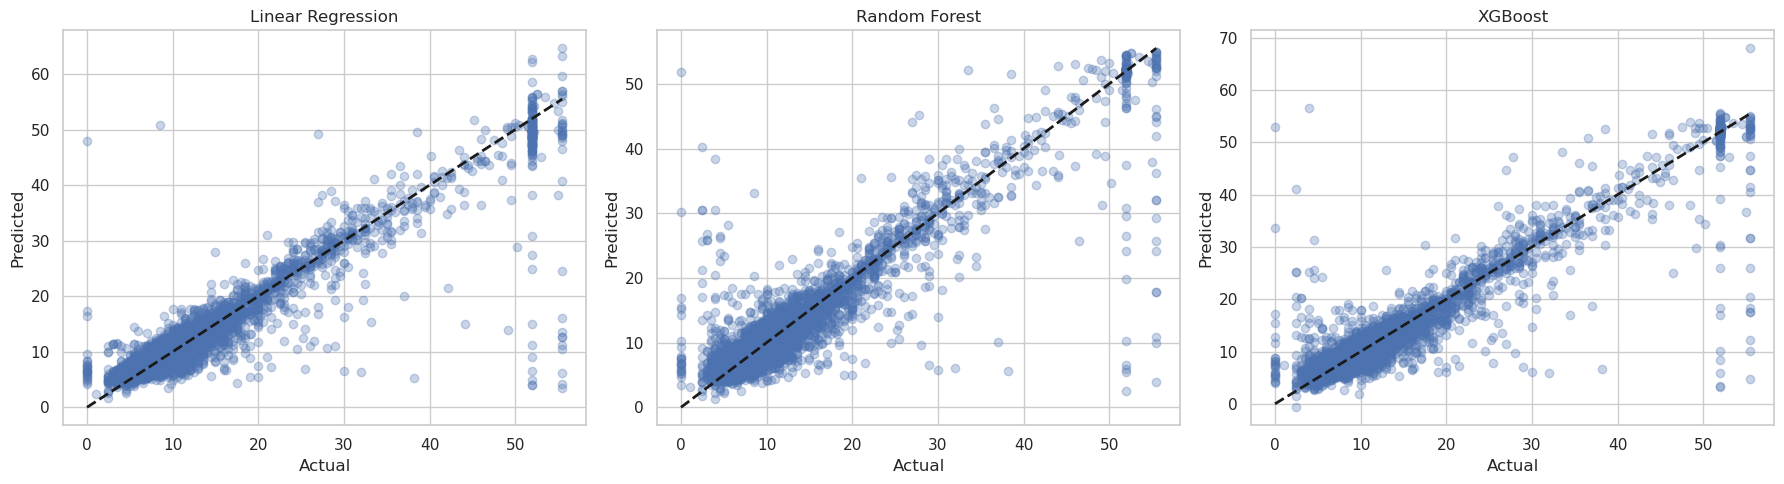

In [72]:
plt.figure(figsize=(18, 5))

# Plot Linear Regression results
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred_test, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linear Regression')

# Plot Random Forest results
plt.subplot(1, 3, 2)
plt.scatter(y_test, y_pred1, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Random Forest')

# Plot XGBoost results
plt.subplot(1, 3, 3)
plt.scatter(y_test, y_pred2, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('XGBoost')

plt.tight_layout()
plt.savefig('./Figures/ScatterAlgo.png', dpi=300) 
plt.show()

## Line Plot for algorithms

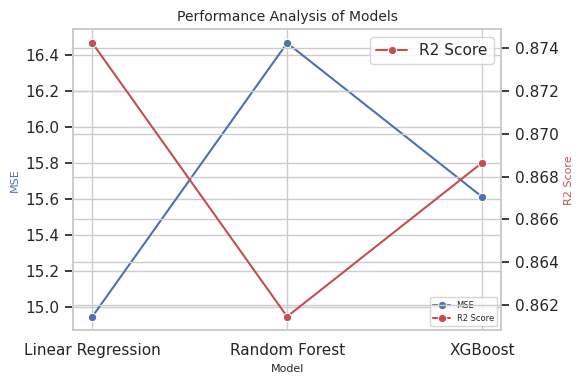

In [82]:
models = ['Linear Regression', 'Random Forest', 'XGBoost']
mse_scores = [14.948803713718371, 16.466342465155613, 15.6139256009934]
r2_scores = [0.8742326390091082, 0.8614652732971264, 0.8686368465423584]

# Create a DataFrame for easier plotting
performance_df = pd.DataFrame({
    'Model': models,
    'MSE': mse_scores,
    'R2 Score': r2_scores
})

# Set the style
sns.set(style='whitegrid')

# Create the line plot with IEEE format size
fig, ax1 = plt.subplots(figsize=(6, 4))  # Single-column width

# Plot MSE
sns.lineplot(x='Model', y='MSE', data=performance_df, marker='o', label='MSE', ax=ax1, color='b')

# Create a second y-axis for R2 Score
ax2 = ax1.twinx()
sns.lineplot(x='Model', y='R2 Score', data=performance_df, marker='o', label='R2 Score', ax=ax2, color='r')

# Set labels and title
ax1.set_xlabel('Model', fontsize=8)
ax1.set_ylabel('MSE', fontsize=8, color='b')
ax2.set_ylabel('R2 Score', fontsize=8, color='r')
plt.title('Performance Analysis of Models', fontsize=10)

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower right', fontsize=6)

# Adjust layout to fit within the figure size
plt.tight_layout()

# Save the figure
plt.savefig('./Figures/Performance_Analysis.png', dpi=300)  # Ensure the file extension is included
plt.show()